### H2 - Price vs Occupancy
#### Among similar listings in the same neighbourhood, is a higher ADR associated with lower occupancy?

#### ADR ↑ → Occupancy ↓ ?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

airbnb = pd.read_csv("airbnb_final.csv")

In [2]:
airbnb.head()

,listing_id,room_type,latitude,longitude,guests,bedrooms,beds,baths,property_type,neighborhood,month_date,available_days,occupancy,avg_daily_rate,revenue,active,booking_lead_time_avg,length_of_stay_avg,revpar
0,14948804,private_room,41.40698,2.18241,2.0,1.0,1.0,1.0,Apartment & Condo,Sant Martí,2021-03-01,31,0.000,24.4,0.0,False,NaN,NaN,0.000000
1,14948804,private_room,41.40698,2.18241,2.0,1.0,1.0,1.0,Apartment & Condo,Sant Martí,2021-04-01,30,0.000,24.3,0.0,False,NaN,NaN,0.000000
2,14948804,private_room,41.40698,2.18241,2.0,1.0,1.0,1.0,Apartment & Condo,Sant Martí,2021-05-01,26,0.161,24.8,125.0,True,NaN,NaN,4.032258
3,14948804,private_room,41.40698,2.18241,2.0,1.0,1.0,1.0,Apartment & Condo,Sant Martí,2021-06-01,30,0.000,24.7,0.0,True,NaN,NaN,0.000000
4,14948804,private_room,41.40698,2.18241,2.0,1.0,1.0,1.0,Apartment & Condo,Sant Martí,2021-07-01,31,0.000,25.0,0.0,True,NaN,NaN,0.000000


In [ ]:
# Filter comparable 2-bedroom entire homes in Eixample

h2 = airbnb[
    (airbnb["neighborhood"] == "Eixample") &
    (airbnb["room_type"] == "entire_home") &
    (airbnb["bedrooms"] == 2)
]

In [ ]:
# checking how many listings we have (2 bedroom / entire home / Eixample)

h2["listing_id"].nunique()

68

In [ ]:
# Aggregate monthly data to one row per listing

h2_grouped = h2.groupby("listing_id")[["avg_daily_rate", "occupancy"]].mean().reset_index()

In [6]:
h2_grouped.head()

,listing_id,avg_daily_rate,occupancy
0,892906,252.868333,0.698567
1,1102498,135.046667,0.748133
2,1383728,160.695000,0.658150
3,2265321,204.323333,0.728850
4,3167271,195.961667,0.794717


In [ ]:
# cleaning a bit 

h2_grouped["avg_daily_rate"] = h2_grouped["avg_daily_rate"].round(2)
h2_grouped["occupancy"] = (h2_grouped["occupancy"] * 100).round(2)

In [8]:
h2_grouped.head()

,listing_id,avg_daily_rate,occupancy
0,892906,252.87,69.86
1,1102498,135.05,74.81
2,1383728,160.70,65.81
3,2265321,204.32,72.89
4,3167271,195.96,79.47


In [ ]:
# Calculate correlation between ADR and occupancy (only for 2-bedroom entire homes in Eixample)

h2_grouped["avg_daily_rate"].corr(h2_grouped["occupancy"])

np.float64(0.34534828090008174)

In [ ]:
# keeping only 2-bedroom entire homes (for all neighbourhoods now) 

similar_listings = airbnb[
    (airbnb["room_type"] == "entire_home") &
    (airbnb["bedrooms"] == 2)
]

# counting how many this kind of listings we have in each neighbourhood 
similar_listings.groupby("neighborhood")["listing_id"].nunique().sort_values(ascending=False)

neighborhood
Eixample                 68
Old Town                 37
Sant Martí               24
Sants-Montjuïc           21
Gràcia                   19
Sarrià - Sant Gervasi    11
Horta-Guinardó            6
Sant Andreu               5
les Corts                 4
Name: listing_id, dtype: int64

In [ ]:
# taking top 5 neighbourhoods with the most listings (2-bedroom entire homes)

top_5_neighborhoods = [
    "Eixample",
    "Old Town",
    "Sant Martí",
    "Sants-Montjuïc",
    "Gràcia"
]

h2 = similar_listings[
    similar_listings["neighborhood"].isin(top_5_neighborhoods)
]

In [ ]:
# calculate mean ADR and occupancy for each listing in each neighborhood

h2_grouped = h2.groupby(
    ["neighborhood", "listing_id"]
)[["avg_daily_rate", "occupancy"]].mean().reset_index()

In [ ]:
# rounding for clear look

h2_grouped["avg_daily_rate"] = h2_grouped["avg_daily_rate"].round(2)
h2_grouped["occupancy"] = (h2_grouped["occupancy"] * 100).round(2)

In [15]:
h2_grouped.head()

,neighborhood,listing_id,avg_daily_rate,occupancy
0,Eixample,892906,252.87,69.86
1,Eixample,1102498,135.05,74.81
2,Eixample,1383728,160.70,65.81
3,Eixample,2265321,204.32,72.89
4,Eixample,3167271,195.96,79.47


In [ ]:
# Calculate correlation between ADR and occupancy for each of the top 5 neighborhoods  

correlations = []

for neighborhood in top_5_neighborhoods:
    area = h2_grouped[h2_grouped["neighborhood"] == neighborhood]
    
    corr = area["avg_daily_rate"].corr(area["occupancy"])
    
    correlations.append([neighborhood, round(corr, 2)])

# little dataframe to see the results
correlations_df = pd.DataFrame(
    correlations,
    columns=["neighborhood", "correlation"]
)

correlations_df

,neighborhood,correlation
0,Eixample,0.35
1,Old Town,0.14
2,Sant Martí,0.73
3,Sants-Montjuïc,0.06
4,Gràcia,-0.13


#### Visualisation

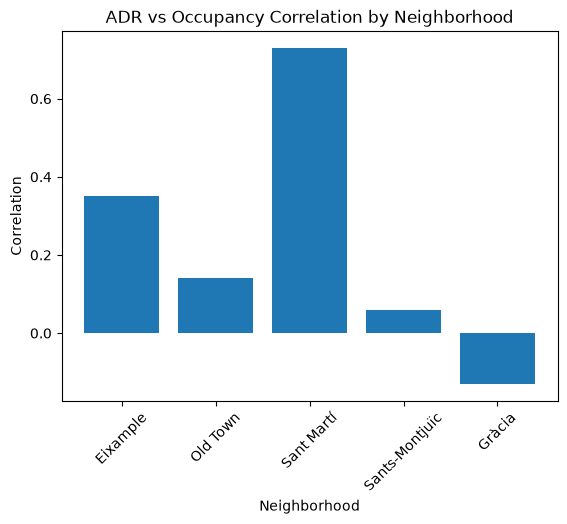

In [17]:
plt.bar(
    correlations_df["neighborhood"],
    correlations_df["correlation"]
)

plt.xlabel("Neighborhood")
plt.ylabel("Correlation")
plt.title("ADR vs Occupancy Correlation by Neighborhood")

plt.xticks(rotation=45)

plt.show()

##### Sample: 169 unique listings — entire_home, 2 bedrooms, across the 5 largest neighbourhoods.
The relationship between ADR and occupancy is not consistently negative. Four of the five neighbourhoods show a positive correlation, while only Gràcia shows a very weak negative correlation.
For this group, higher ADR is not associated with lower occupancy.

In [ ]:
# here I decided that one type of property is not enough for solid conclusion, so I'm taking also private room + 1 bedroom for the same analysis

private_rooms = airbnb[
    (airbnb["room_type"] == "private_room") &
    (airbnb["bedrooms"] == 1)
]

private_rooms.groupby("neighborhood")["listing_id"].nunique().sort_values(ascending=False)

neighborhood
Eixample                 76
Old Town                 70
Sants-Montjuïc           21
Sant Martí               20
Gràcia                   14
Sarrià - Sant Gervasi    10
Horta-Guinardó            9
Nou Barris                6
les Corts                 3
Sant Andreu               2
Name: listing_id, dtype: int64

In [ ]:
# same, top 5 neighbourhoods with the most listings (1-bedroom private rooms)

top_5_private = [
    "Eixample",
    "Old Town",
    "Sants-Montjuïc",
    "Sant Martí",
    "Gràcia"
]

h2_private = private_rooms[
    private_rooms["neighborhood"].isin(top_5_private)
]

In [ ]:
# calculate mean adr and occupancy for each listing in each neighborhood

h2_private_grouped = h2_private.groupby(
    ["neighborhood", "listing_id"]
)[["avg_daily_rate", "occupancy"]].mean().reset_index()

In [ ]:
# rounding for clear look

h2_private_grouped["avg_daily_rate"] = h2_private_grouped["avg_daily_rate"].round(2)
h2_private_grouped["occupancy"] = (h2_private_grouped["occupancy"] * 100).round(2)

In [ ]:
# checking how many listings we have (1 bedroom / private room / top 5 neighborhoods)

h2_private_grouped["listing_id"].nunique()

201

In [ ]:
# Calculate correlation between ADR and occupancy for each of the top 5 neighborhoods (1-bedroom private rooms)

correlations_private = []

for neighborhood in top_5_private:
    area = h2_private_grouped[
        h2_private_grouped["neighborhood"] == neighborhood
    ]

    corr = area["avg_daily_rate"].corr(area["occupancy"])

    correlations_private.append([
        neighborhood,
        round(corr, 2)
    ])

# little dataframe to see the results
correlations_private_df = pd.DataFrame(
    correlations_private,
    columns=["neighborhood", "correlation"]
)

correlations_private_df

,neighborhood,correlation
0,Eixample,0.01
1,Old Town,-0.13
2,Sants-Montjuïc,0.44
3,Sant Martí,-0.08
4,Gràcia,-0.07


#### Visualisation

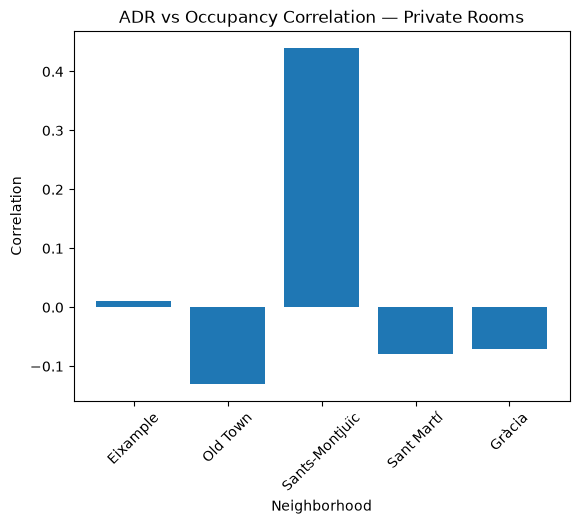

In [24]:
plt.bar(
    correlations_private_df["neighborhood"],
    correlations_private_df["correlation"]
)

plt.xlabel("Neighborhood")
plt.ylabel("Correlation")
plt.title("ADR vs Occupancy Correlation — Private Rooms")

plt.xticks(rotation=45)

plt.show()

In [ ]:
# combining the two correlation ddataframes (private rooms/1bd and entire homes/2bd)

comparison = correlations_df.merge(
    correlations_private_df,
    on="neighborhood",
    suffixes=("_entire_home", "_private_room")
)

comparison

,neighborhood,correlation_entire_home,correlation_private_room
0,Eixample,0.35,0.01
1,Old Town,0.14,-0.13
2,Sant Martí,0.73,-0.08
3,Sants-Montjuïc,0.06,0.44
4,Gràcia,-0.13,-0.07


#### Final Visualisation

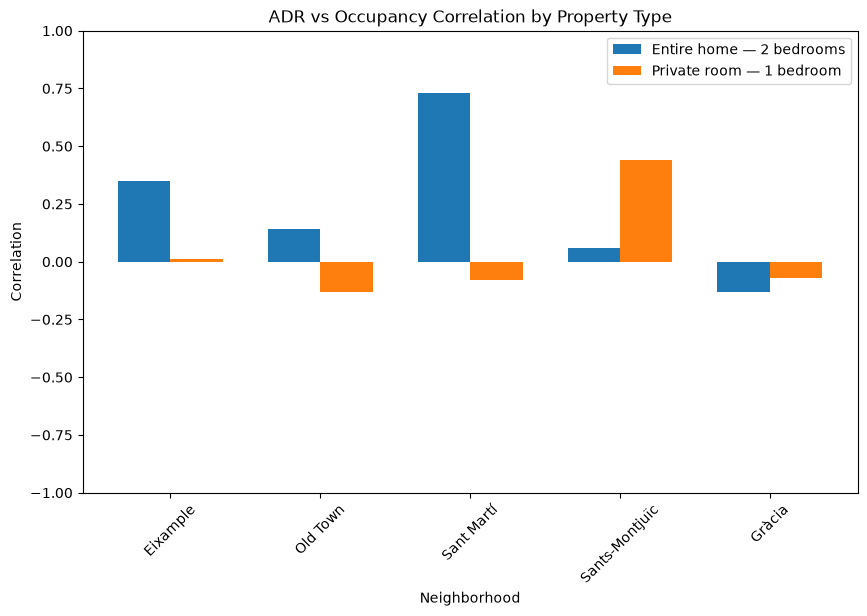

In [27]:
import numpy as np

x = np.arange(len(comparison["neighborhood"]))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    comparison["correlation_entire_home"],
    width,
    label="Entire home — 2 bedrooms"
)

plt.bar(
    x + width/2,
    comparison["correlation_private_room"],
    width,
    label="Private room — 1 bedroom"
)

plt.xticks(x, comparison["neighborhood"], rotation=45)
plt.xlabel("Neighborhood")
plt.ylabel("Correlation")
plt.title("ADR vs Occupancy Correlation by Property Type")
plt.ylim(-1, 1)
plt.legend()

plt.show()

#### H2 — NOT SUPPORTED
##### Samples
- 169 listings: Entire home, 2 bedrooms, top 5 neighbourhoods
- 201 listings: Private room, 1 bedroom, top 5 neighbourhoods
- Total: 370 unique listings
#### Conclusion
Across both comparable samples, higher ADR is not consistently associated with lower occupancy. Most correlations are weak, close to zero, or positive.

### Higher ADR does not appear to reduce occupancy in this dataset.